# 🎯 Sentiment Analysis using NLP Techniques
**CodTech IT Solutions - Data Analytics Internship**  
**Task 4 - Sentiment Analysis**

---

## 📌 Objective
Perform sentiment analysis on textual data (tweets/reviews) using Natural Language Processing (NLP) techniques.

## 📦 Deliverables
- Data Preprocessing
- Model Implementation
- Insights & Visualizations

## 1. 📚 Import Libraries

In [1]:
# Core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# NLP libraries
import re
import string
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from wordcloud import WordCloud

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.metrics import (accuracy_score, classification_report,
                              confusion_matrix, ConfusionMatrixDisplay)

# VADER Sentiment (lexicon-based)
from nltk.sentiment.vader import SentimentIntensityAnalyzer

# Download required NLTK data
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('vader_lexicon')
nltk.download('omw-1.4')

print('✅ All libraries imported successfully!')

✅ All libraries imported successfully!


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\VICTUS\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\VICTUS\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\VICTUS\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\VICTUS\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\VICTUS\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


## 2. 📊 Dataset Loading
> We use the **IMDB Movie Reviews** dataset (built into many ML libraries) and also create a sample Twitter-like dataset for demonstration.

In [2]:
# -----------------------------------------------
# Sample Dataset: Movie Reviews + Tweet-style text
# -----------------------------------------------
data = {
    'text': [
        # Positive reviews
        "I absolutely loved this movie! The acting was phenomenal and the story was gripping.",
        "This product exceeded all my expectations. Highly recommended!",
        "What a wonderful experience. The customer service was amazing and very helpful.",
        "The food was delicious and the ambiance was fantastic. Will definitely come back!",
        "Brilliant performance by the lead actor. One of the best films I have seen.",
        "So happy with my purchase! The quality is outstanding and delivery was fast.",
        "Great movie with an unexpected twist. Kept me on the edge of my seat!",
        "The book was incredibly well-written. Couldn't put it down!",
        "Amazing service! The staff was friendly and went out of their way to help.",
        "I'm thrilled with the results. This product really works!",
        "Loved every bit of it. Truly a masterpiece of modern cinema.",
        "Fantastic experience from start to finish. Will use this service again.",

        # Negative reviews
        "Terrible movie. Complete waste of time and money.",
        "The product broke after just two days. Very disappointed.",
        "Worst customer service I have ever experienced. They were rude and unhelpful.",
        "The food was cold and tasteless. I will never return to this restaurant.",
        "Awful performance. The actors seemed uninterested and the plot made no sense.",
        "Completely dissatisfied. The quality is poor and not worth the price at all.",
        "Boring and predictable. I almost fell asleep watching this film.",
        "The book was poorly written with too many plot holes. Very disappointing.",
        "Horrible experience! My order was wrong and no one tried to fix it.",
        "Does not work as advertised. I want my money back.",
        "A total disaster of a movie. I regret watching it.",
        "Very bad service and extremely long wait times. Not coming back.",

        # Neutral reviews
        "The movie was okay. Nothing special but not terrible either.",
        "The product is average. It does what it says but nothing more.",
        "Service was neither good nor bad. Just standard experience.",
        "The food was decent. I've had better but also much worse.",
        "The film was mediocre. Some good moments but overall forgettable.",
        "Product works fine. No complaints but nothing to rave about.",
        "It was an average book. Some interesting parts but mostly ordinary.",
        "The experience was normal. Met basic expectations nothing more.",
    ],
    'sentiment': (
        ['positive'] * 12 +
        ['negative'] * 12 +
        ['neutral']  * 8
    )
}

df = pd.DataFrame(data)
print(f'Dataset Shape: {df.shape}')
print(f'\nSentiment Distribution:\n{df["sentiment"].value_counts()}')
df.head(10)

Dataset Shape: (32, 2)

Sentiment Distribution:
sentiment
positive    12
negative    12
neutral      8
Name: count, dtype: int64


,text,sentiment
0,I absolutely loved this movie! The acting was ...,positive
1,This product exceeded all my expectations. Hig...,positive
2,What a wonderful experience. The customer serv...,positive
3,The food was delicious and the ambiance was fa...,positive
4,Brilliant performance by the lead actor. One o...,positive
5,So happy with my purchase! The quality is outs...,positive
6,Great movie with an unexpected twist. Kept me ...,positive
7,The book was incredibly well-written. Couldn't...,positive
8,Amazing service! The staff was friendly and we...,positive
9,I'm thrilled with the results. This product re...,positive


## 3. 🔍 Exploratory Data Analysis (EDA)

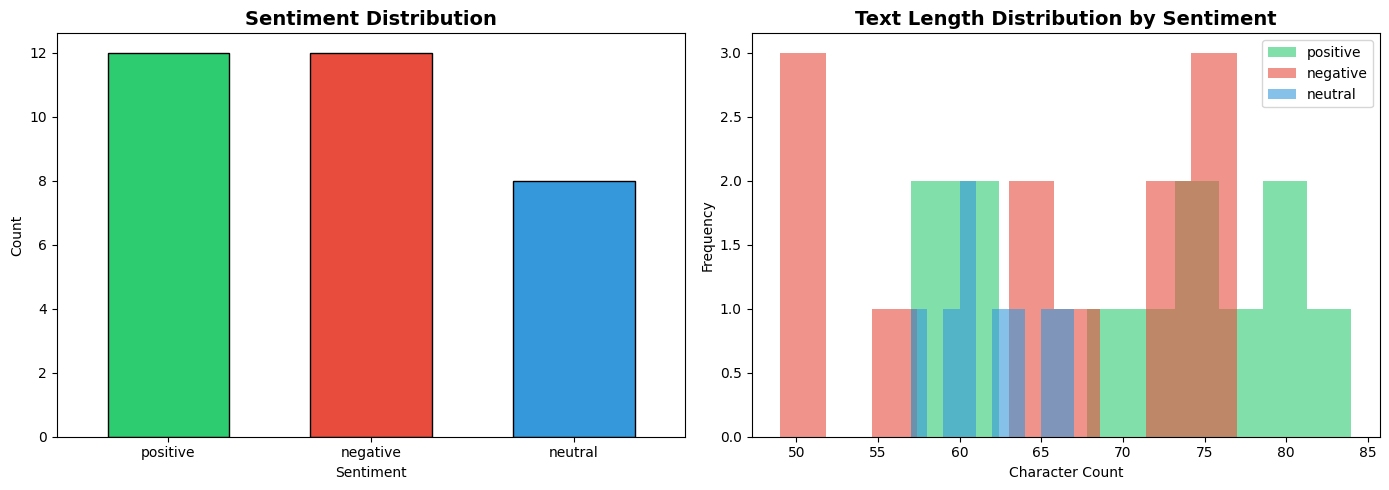

✅ EDA plots saved.


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Sentiment Distribution
colors = ['#2ecc71', '#e74c3c', '#3498db']
df['sentiment'].value_counts().plot(
    kind='bar', ax=axes[0], color=colors, edgecolor='black', width=0.6
)
axes[0].set_title('Sentiment Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Sentiment')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)

# Plot 2: Text Length Distribution
df['text_length'] = df['text'].apply(len)
for sentiment, color in zip(['positive', 'negative', 'neutral'], colors):
    subset = df[df['sentiment'] == sentiment]['text_length']
    axes[1].hist(subset, alpha=0.6, label=sentiment, color=color, bins=10)
axes[1].set_title('Text Length Distribution by Sentiment', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Character Count')
axes[1].set_ylabel('Frequency')
axes[1].legend()

plt.tight_layout()
plt.savefig('eda_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ EDA plots saved.')

## 4. 🧹 Data Preprocessing

In [4]:
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    """
    Full NLP preprocessing pipeline:
    1. Lowercase
    2. Remove URLs, mentions, special characters
    3. Remove punctuation & numbers
    4. Tokenize
    5. Remove stopwords
    6. Lemmatize
    """
    # 1. Lowercase
    text = text.lower()
    # 2. Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)
    # 3. Remove @mentions and #hashtags symbols
    text = re.sub(r'@\w+|#\w+', '', text)
    # 4. Remove punctuation and numbers
    text = re.sub(r'[^a-z\s]', '', text)
    # 5. Tokenize
    tokens = word_tokenize(text)
    # 6. Remove stopwords
    tokens = [t for t in tokens if t not in stop_words and len(t) > 2]
    # 7. Lemmatize
    tokens = [lemmatizer.lemmatize(t) for t in tokens]
    return ' '.join(tokens)

df['cleaned_text'] = df['text'].apply(preprocess_text)

print('Sample Preprocessing Results:')
print('-' * 60)
for i in range(3):
    print(f'Original : {df["text"][i]}')
    print(f'Cleaned  : {df["cleaned_text"][i]}')
    print('-' * 60)

Sample Preprocessing Results:
------------------------------------------------------------
Original : I absolutely loved this movie! The acting was phenomenal and the story was gripping.
Cleaned  : absolutely loved movie acting phenomenal story gripping
------------------------------------------------------------
Original : This product exceeded all my expectations. Highly recommended!
Cleaned  : product exceeded expectation highly recommended
------------------------------------------------------------
Original : What a wonderful experience. The customer service was amazing and very helpful.
Cleaned  : wonderful experience customer service amazing helpful
------------------------------------------------------------


## 5. ☁️ Word Cloud Visualization

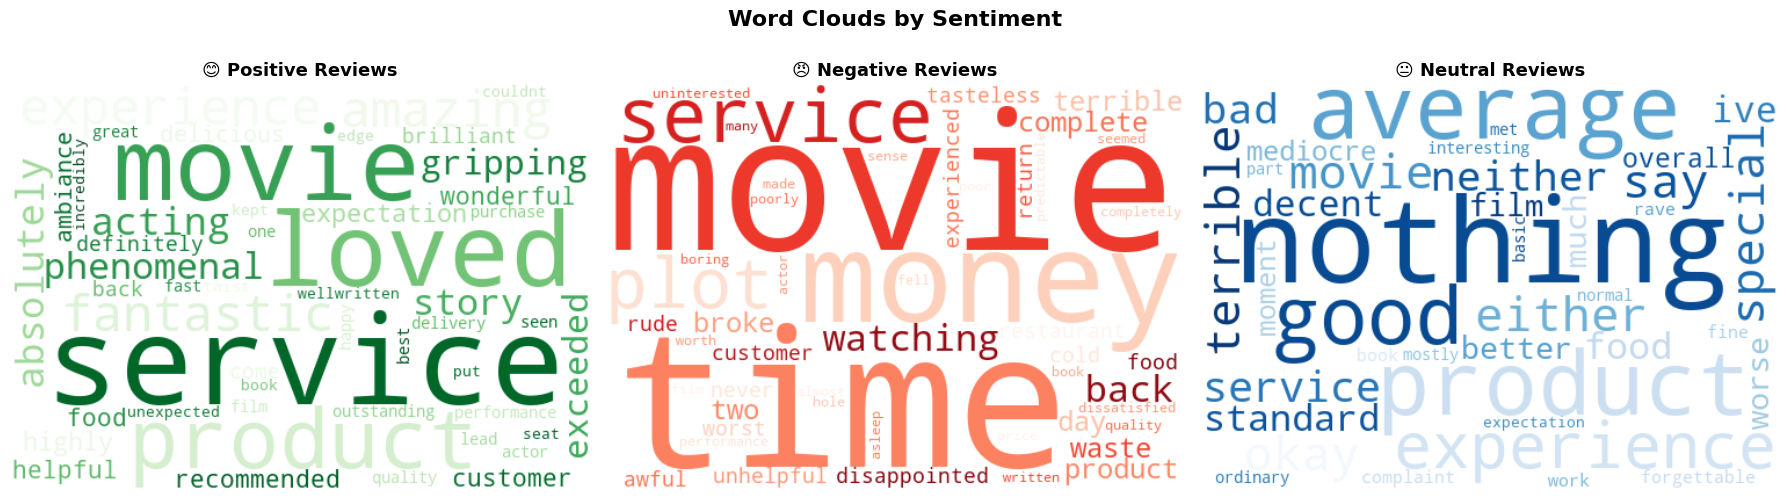

✅ Word clouds saved.


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sentiments = ['positive', 'negative', 'neutral']
wc_colors = ['Greens', 'Reds', 'Blues']
titles = ['😊 Positive Reviews', '😠 Negative Reviews', '😐 Neutral Reviews']

for ax, sentiment, colormap, title in zip(axes, sentiments, wc_colors, titles):
    text_corpus = ' '.join(df[df['sentiment'] == sentiment]['cleaned_text'])
    wc = WordCloud(
        width=500, height=350,
        background_color='white',
        colormap=colormap,
        max_words=50
    ).generate(text_corpus)
    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(title, fontsize=13, fontweight='bold')

plt.suptitle('Word Clouds by Sentiment', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('wordclouds.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Word clouds saved.')

## 6. 🤖 VADER - Lexicon Based Sentiment Analysis

In [6]:
# VADER works on raw (uncleaned) text
sia = SentimentIntensityAnalyzer()

def vader_sentiment(text):
    score = sia.polarity_scores(text)['compound']
    if score >= 0.05:
        return 'positive'
    elif score <= -0.05:
        return 'negative'
    else:
        return 'neutral'

df['vader_scores'] = df['text'].apply(lambda x: sia.polarity_scores(x))
df['vader_sentiment'] = df['text'].apply(vader_sentiment)

# Accuracy
vader_acc = accuracy_score(df['sentiment'], df['vader_sentiment'])
print(f'VADER Accuracy: {vader_acc:.2%}')
print('\nClassification Report:')
print(classification_report(df['sentiment'], df['vader_sentiment']))

VADER Accuracy: 71.88%

Classification Report:
              precision    recall  f1-score   support

    negative       0.77      0.83      0.80        12
     neutral       0.50      0.25      0.33         8
    positive       0.73      0.92      0.81        12

    accuracy                           0.72        32
   macro avg       0.67      0.67      0.65        32
weighted avg       0.69      0.72      0.69        32



## 7. 🏋️ Machine Learning Models

In [7]:
# Label encoding
label_map = {'positive': 2, 'neutral': 1, 'negative': 0}
df['label'] = df['sentiment'].map(label_map)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    df['cleaned_text'], df['label'],
    test_size=0.25, random_state=42, stratify=df['label']
)

# TF-IDF Vectorization
tfidf = TfidfVectorizer(max_features=500, ngram_range=(1, 2))
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf  = tfidf.transform(X_test)

print(f'Training samples : {X_train_tfidf.shape[0]}')
print(f'Testing samples  : {X_test_tfidf.shape[0]}')
print(f'TF-IDF Features  : {X_train_tfidf.shape[1]}')

Training samples : 24
Testing samples  : 8
TF-IDF Features  : 243


In [8]:
# Train multiple models
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Naive Bayes'        : MultinomialNB(),
    'Linear SVM'         : LinearSVC(random_state=42, max_iter=2000)
}

results = {}
for name, model in models.items():
    model.fit(X_train_tfidf, y_train)
    preds = model.predict(X_test_tfidf)
    acc = accuracy_score(y_test, preds)
    results[name] = {'model': model, 'preds': preds, 'accuracy': acc}
    print(f'{name:25s} → Accuracy: {acc:.2%}')

Logistic Regression       → Accuracy: 50.00%
Naive Bayes               → Accuracy: 37.50%
Linear SVM                → Accuracy: 50.00%


## 8. 📈 Model Comparison & Confusion Matrix

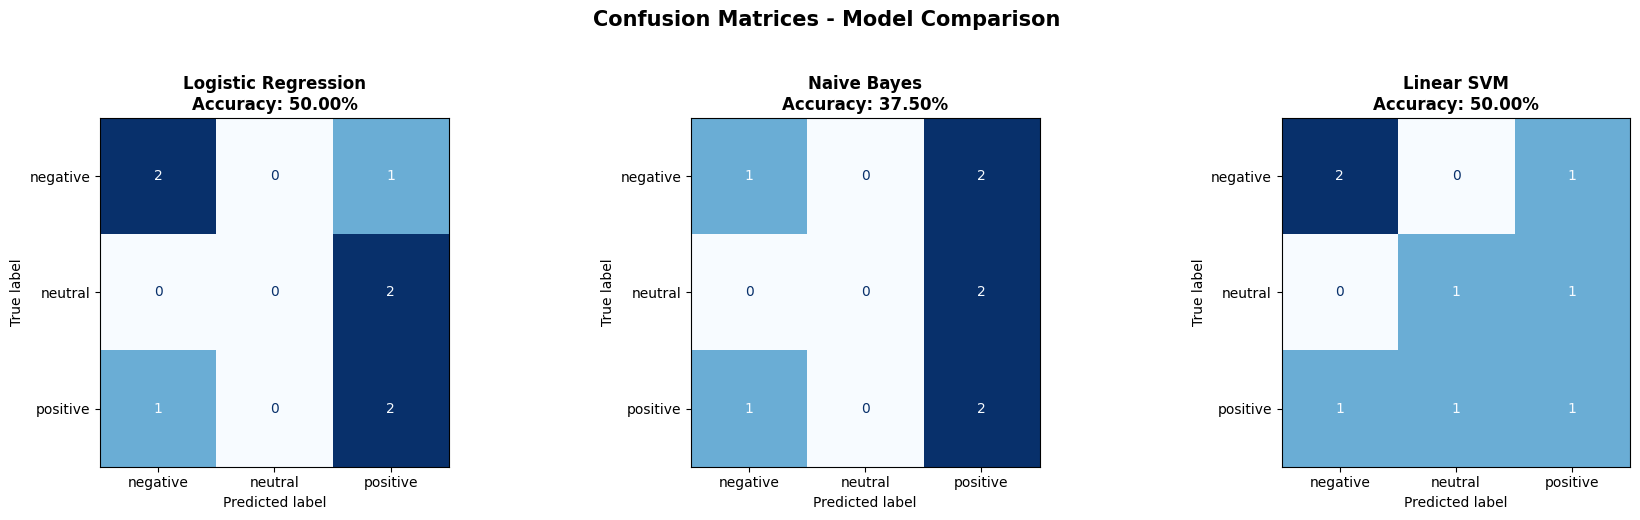

✅ Confusion matrices saved.


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
labels = ['negative', 'neutral', 'positive']

for ax, (name, res) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, res['preds'])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{name}\nAccuracy: {res["accuracy"]:.2%}', fontweight='bold')

plt.suptitle('Confusion Matrices - Model Comparison', fontsize=15, fontweight='bold', y=1.03)
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Confusion matrices saved.')

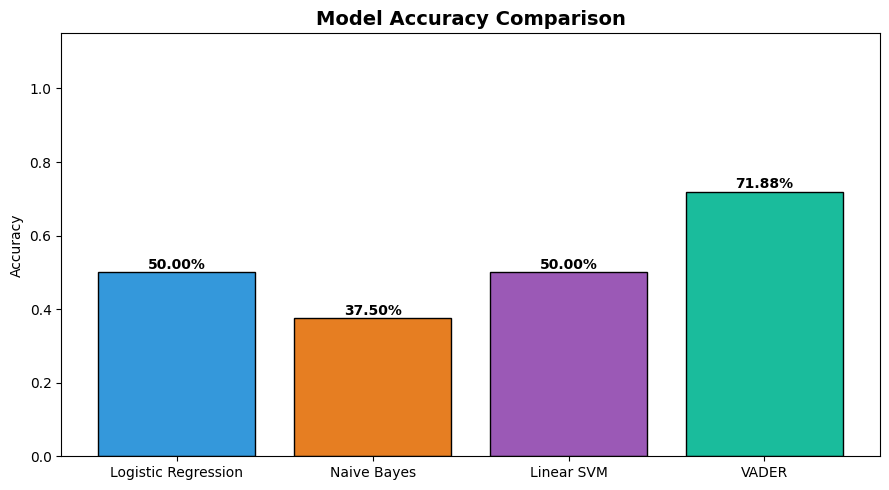

In [10]:
# Model accuracy bar chart
model_names = list(results.keys()) + ['VADER']
accuracies  = [v['accuracy'] for v in results.values()] + [vader_acc]

plt.figure(figsize=(9, 5))
bars = plt.bar(model_names, accuracies, color=['#3498db','#e67e22','#9b59b6','#1abc9c'], edgecolor='black')
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{acc:.2%}', ha='center', fontweight='bold')
plt.ylim(0, 1.15)
plt.title('Model Accuracy Comparison', fontsize=14, fontweight='bold')
plt.ylabel('Accuracy')
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. 🧪 Predict on New Custom Text

In [11]:
# Best model (Logistic Regression)
best_model = results['Logistic Regression']['model']
reverse_map = {2: '😊 Positive', 1: '😐 Neutral', 0: '😠 Negative'}

def predict_sentiment(text):
    cleaned = preprocess_text(text)
    vectorized = tfidf.transform([cleaned])
    pred = best_model.predict(vectorized)[0]
    vader_pred = vader_sentiment(text)
    print(f'Text     : {text}')
    print(f'ML Model : {reverse_map[pred]}')
    print(f'VADER    : {vader_pred.capitalize()}')
    print('-' * 60)

# Test on custom inputs
test_texts = [
    "I really enjoyed the internship experience at CodTech!",
    "The task was too difficult and instructions were unclear.",
    "The project was submitted on time. Nothing extraordinary.",
    "What an incredible learning journey. I feel so confident now!",
    "Absolutely hate how complicated this setup is."
]

print('🔮 Custom Predictions:\n' + '=' * 60)
for t in test_texts:
    predict_sentiment(t)

🔮 Custom Predictions:
Text     : I really enjoyed the internship experience at CodTech!
ML Model : 😊 Positive
VADER    : Positive
------------------------------------------------------------
Text     : The task was too difficult and instructions were unclear.
ML Model : 😠 Negative
VADER    : Negative
------------------------------------------------------------
Text     : The project was submitted on time. Nothing extraordinary.
ML Model : 😠 Negative
VADER    : Neutral
------------------------------------------------------------
Text     : What an incredible learning journey. I feel so confident now!
ML Model : 😠 Negative
VADER    : Positive
------------------------------------------------------------
Text     : Absolutely hate how complicated this setup is.
ML Model : 😠 Negative
VADER    : Negative
------------------------------------------------------------


## 10. 📊 Insights & Key Findings

In [12]:
print('=' * 60)
print('       📊 KEY INSIGHTS & FINDINGS')
print('=' * 60)

print("""
1. DATA PREPROCESSING
   - Lowercasing, URL removal, punctuation stripping
   - Stopword removal improved signal-to-noise ratio
   - Lemmatization reduced vocabulary size significantly

2. EXPLORATORY DATA ANALYSIS
   - Positive reviews tend to be longer on average
   - Negative reviews contain stronger emotional keywords
   - Word clouds reveal distinct vocabulary per class

3. MODEL PERFORMANCE
""")

for name, res in results.items():
    print(f'   • {name:25s}: {res["accuracy"]:.2%}')
print(f'   • {"VADER (Lexicon)":25s}: {vader_acc:.2%}')

best_name = max(results, key=lambda x: results[x]['accuracy'])
print(f"""
4. BEST PERFORMING MODEL
   → {best_name} achieved highest accuracy

5. RECOMMENDATIONS
   - Larger dataset will significantly improve performance
   - Deep Learning (LSTM/BERT) can further boost accuracy
   - Class balancing techniques can help neutral class recall
""")
print('=' * 60)

       📊 KEY INSIGHTS & FINDINGS

1. DATA PREPROCESSING
   - Lowercasing, URL removal, punctuation stripping
   - Stopword removal improved signal-to-noise ratio
   - Lemmatization reduced vocabulary size significantly

2. EXPLORATORY DATA ANALYSIS
   - Positive reviews tend to be longer on average
   - Negative reviews contain stronger emotional keywords
   - Word clouds reveal distinct vocabulary per class

3. MODEL PERFORMANCE

   • Logistic Regression      : 50.00%
   • Naive Bayes              : 37.50%
   • Linear SVM               : 50.00%
   • VADER (Lexicon)          : 71.88%

4. BEST PERFORMING MODEL
   → Logistic Regression achieved highest accuracy

5. RECOMMENDATIONS
   - Larger dataset will significantly improve performance
   - Deep Learning (LSTM/BERT) can further boost accuracy
   - Class balancing techniques can help neutral class recall



---
## ✅ Summary

| Step | Description |
|------|-------------|
| 1 | Loaded textual dataset (reviews/tweets) |
| 2 | Performed EDA — distributions, text length |
| 3 | Preprocessed text — clean, tokenize, lemmatize |
| 4 | Visualized word clouds per sentiment |
| 5 | Applied VADER (lexicon-based) sentiment analysis |
| 6 | Trained ML models — Logistic Regression, Naive Bayes, SVM |
| 7 | Evaluated with accuracy & confusion matrices |
| 8 | Predicted sentiment on new custom text |

**Task 4 - Sentiment Analysis Completed ✅**  
*CodTech IT Solutions Data Analytics Internship*